# Financial Risk for Loan Approval


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('Loan.csv')
print(df.head())

  ApplicationDate  Age  AnnualIncome  CreditScore EmploymentStatus  \
0        1/1/2018   45         39948          617         Employed   
1        1/2/2018   38         39709          628         Employed   
2        1/3/2018   47         40724          570         Employed   
3        1/4/2018   58         69084          545         Employed   
4        1/5/2018   37        103264          594         Employed   

  EducationLevel  Experience  LoanAmount  LoanDuration MaritalStatus  ...  \
0         Master          22       13152            48       Married  ...   
1      Associate          15       26045            48        Single  ...   
2       Bachelor          26       17627            36       Married  ...   
3    High School          34       37898            96        Single  ...   
4      Associate          17        9184            36       Married  ...   

   TotalLiabilities MonthlyIncome  UtilityBillsPaymentHistory  JobTenure  \
0             19183   3329.000000       

In [ ]:
X = df.drop('LoanApproved', axis=1)
y = df['LoanApproved']

In [ ]:
# If the variable only has 1 unique value, remove it from X

cols_to_remove = [col for col in X.columns if X[col].nunique() == 1]
X = X.drop(columns=cols_to_remove)
print("removed columns",cols_to_remove)
print(X.shape)

removed columns []
(20000, 34)


In [ ]:
# Check is there any missing values

print(X.isnull().sum())

ApplicationDate               0
Age                           0
AnnualIncome                  0
CreditScore                   0
EmploymentStatus              0
EducationLevel                0
Experience                    0
LoanAmount                    0
LoanDuration                  0
MaritalStatus                 0
NumberOfDependents            0
HomeOwnershipStatus           0
MonthlyDebtPayments           0
CreditCardUtilizationRate     0
NumberOfOpenCreditLines       0
NumberOfCreditInquiries       0
DebtToIncomeRatio             0
BankruptcyHistory             0
LoanPurpose                   0
PreviousLoanDefaults          0
PaymentHistory                0
LengthOfCreditHistory         0
SavingsAccountBalance         0
CheckingAccountBalance        0
TotalAssets                   0
TotalLiabilities              0
MonthlyIncome                 0
UtilityBillsPaymentHistory    0
JobTenure                     0
NetWorth                      0
BaseInterestRate              0
Interest

### There are no any null values in the dataset ###

In [ ]:
# Check the skewness of each variables in dataset
for col in X.columns:
    if pd.api.types.is_numeric_dtype(X[col]):
        skew_value = X[col].skew()
        print(f"Skewness of {col}: {skew_value}")

Skewness of Age: 0.1859639313618668
Skewness of AnnualIncome: 2.088947958524819
Skewness of CreditScore: -0.5967271396622066
Skewness of Experience: 0.3399806516192076
Skewness of LoanAmount: 1.833687791747409
Skewness of LoanDuration: 0.6513298388142006
Skewness of NumberOfDependents: 0.6399193421240162
Skewness of MonthlyDebtPayments: 1.6534346778754938
Skewness of CreditCardUtilizationRate: 0.6011310014982273
Skewness of NumberOfOpenCreditLines: 0.5996617764765775
Skewness of NumberOfCreditInquiries: 1.012064821175029
Skewness of DebtToIncomeRatio: 0.5938584679203655
Skewness of BankruptcyHistory: 4.017671996623785
Skewness of PreviousLoanDefaults: 2.665940998996204
Skewness of PaymentHistory: 0.2134654860091922
Skewness of LengthOfCreditHistory: 0.002988582961076192
Skewness of SavingsAccountBalance: 6.060098547056525
Skewness of CheckingAccountBalance: 4.74614205563194
Skewness of TotalAssets: 5.311326403353311
Skewness of TotalLiabilities: 5.848873989948605
Skewness of MonthlyInc

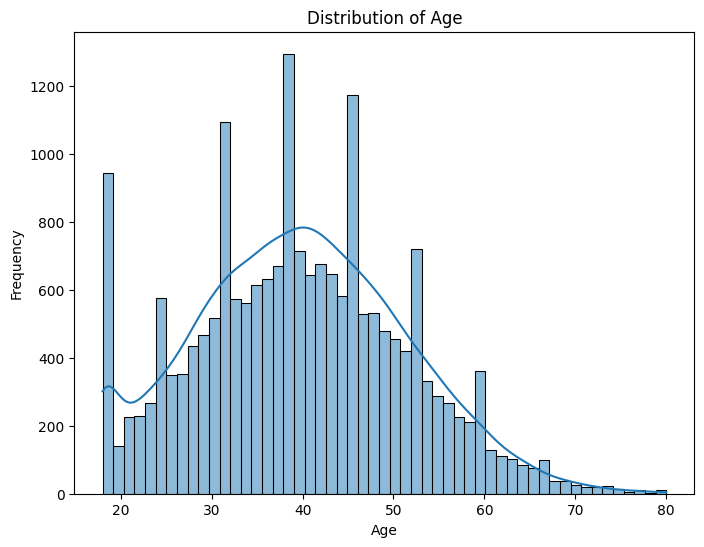

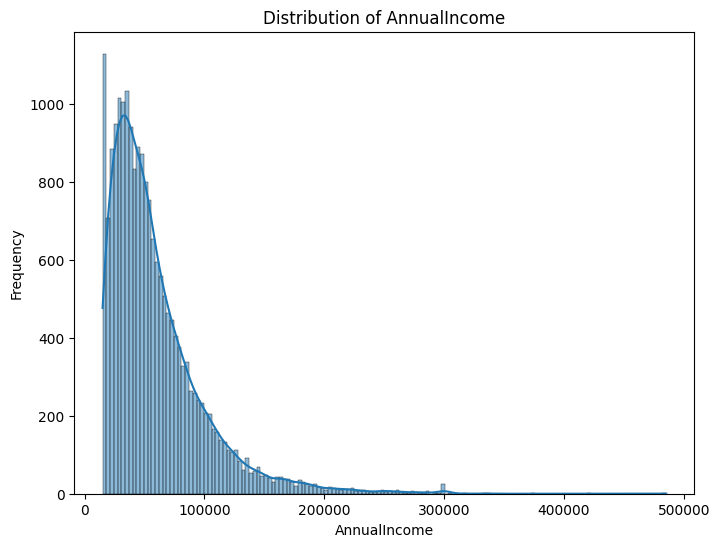

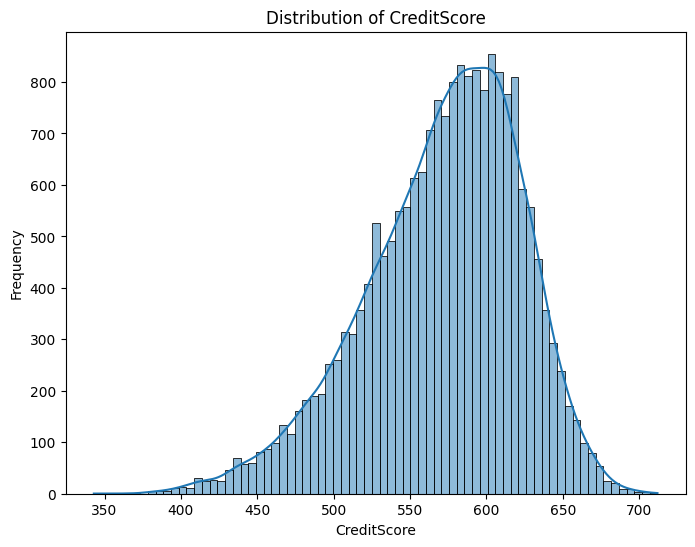

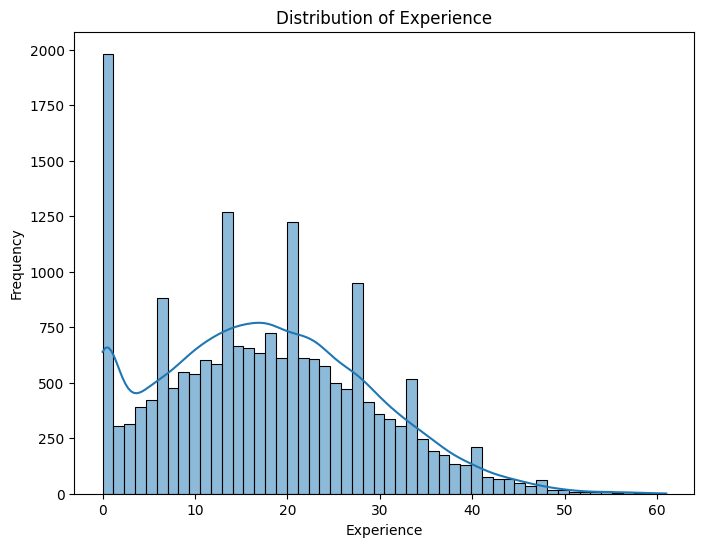

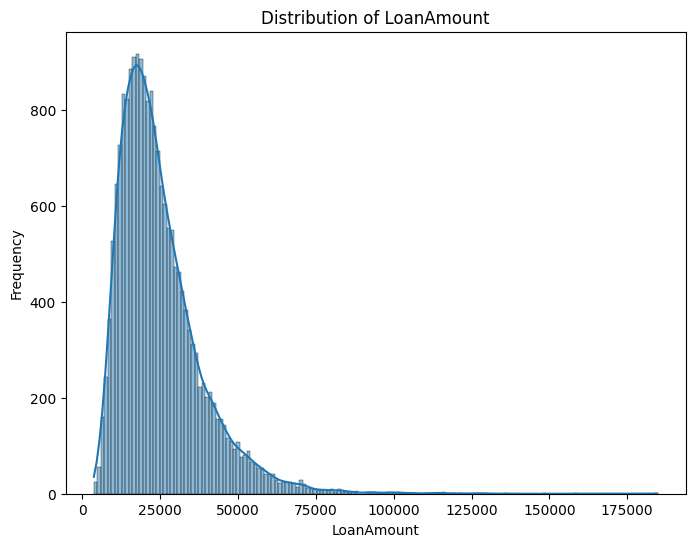

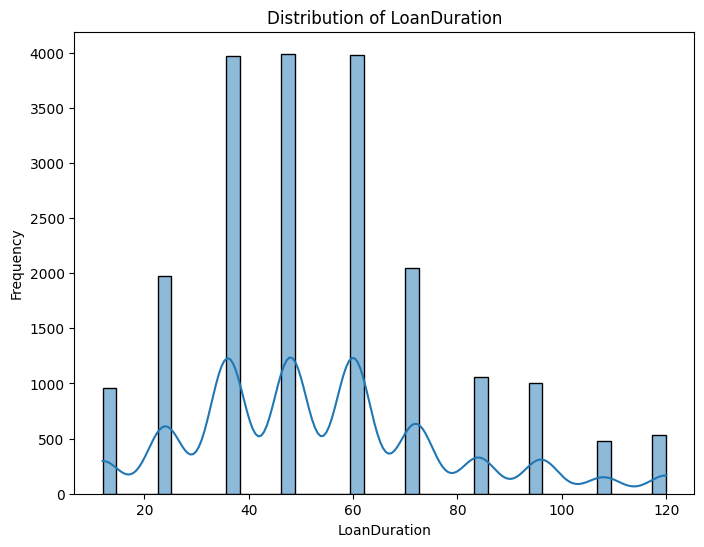

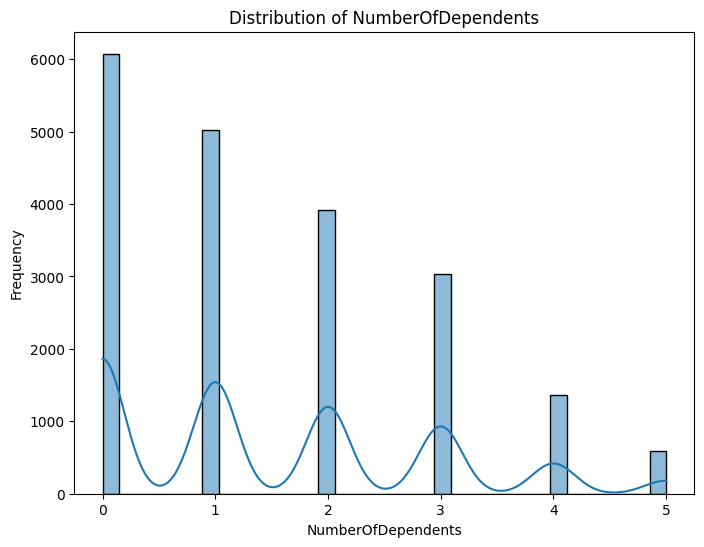

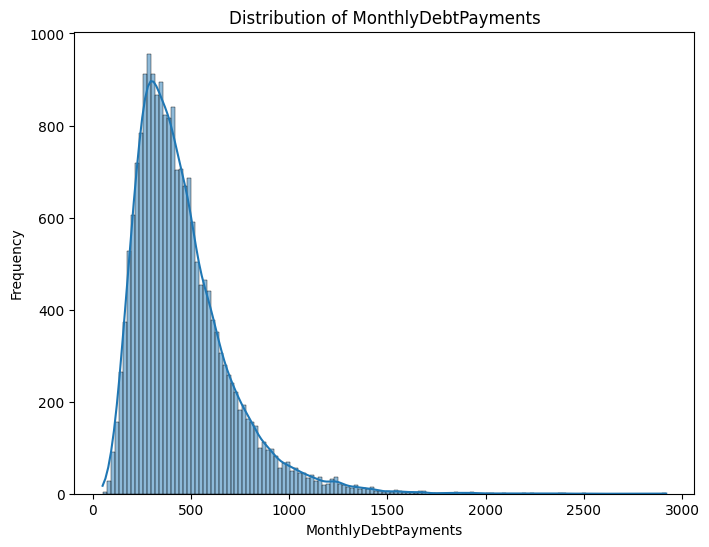

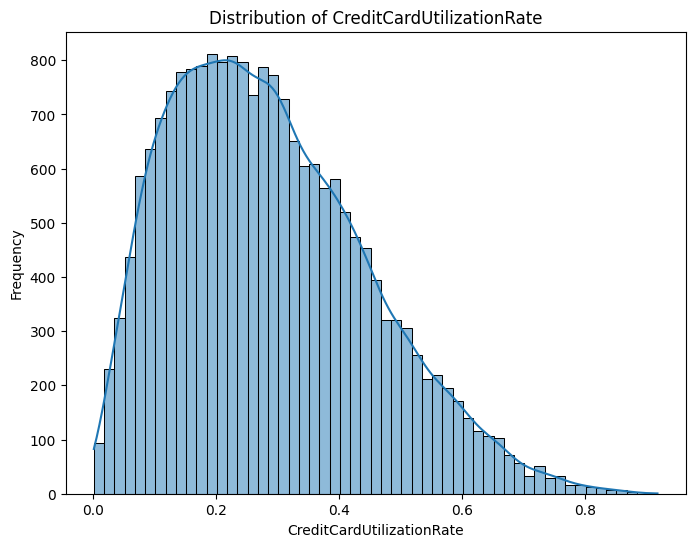

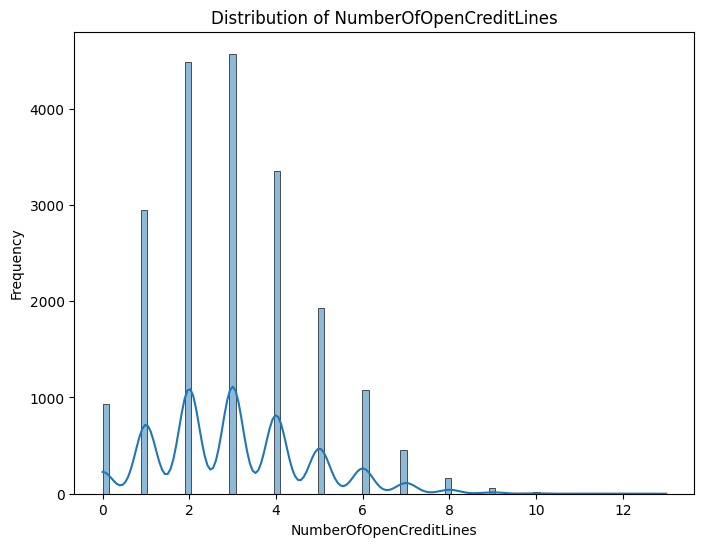

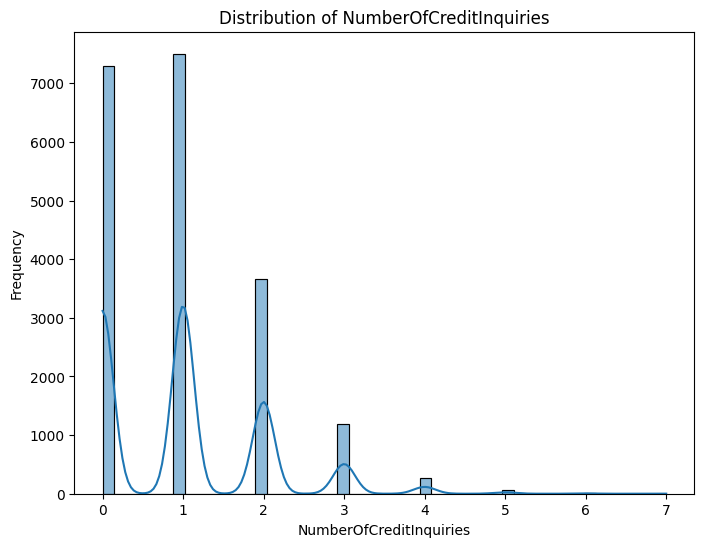

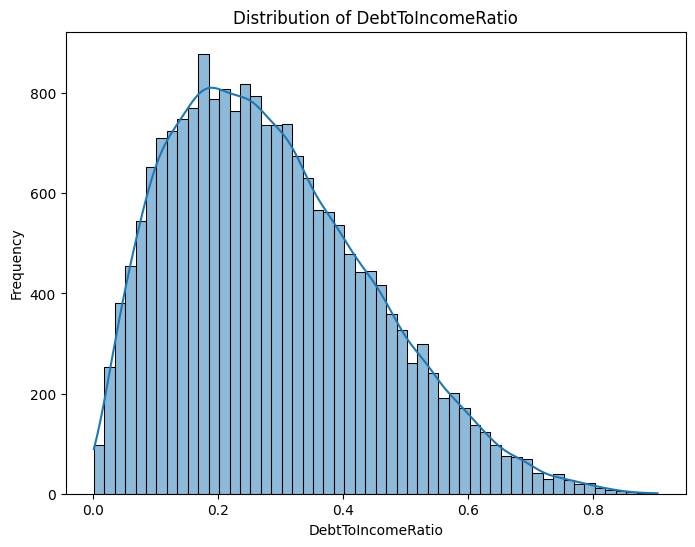

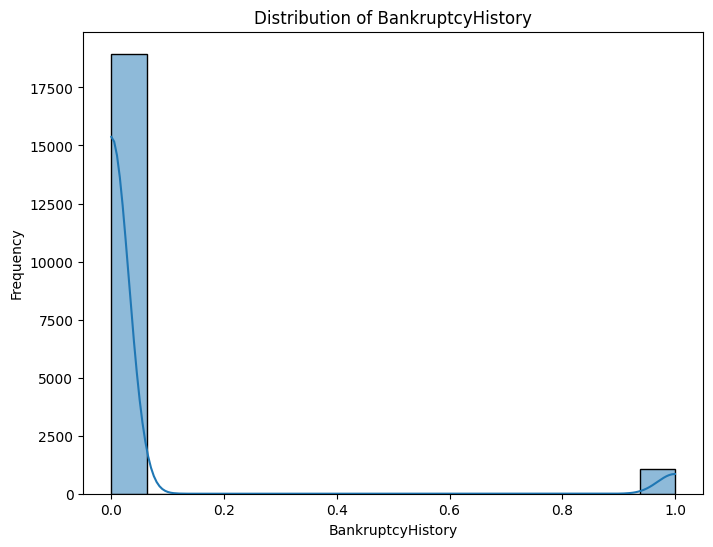

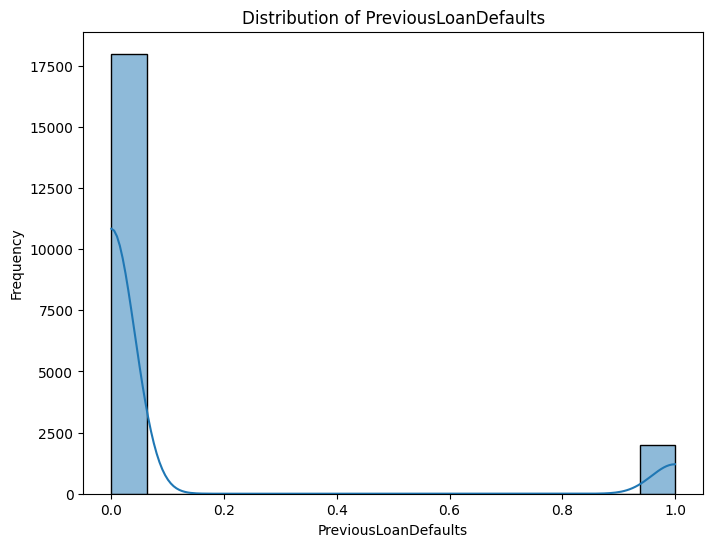

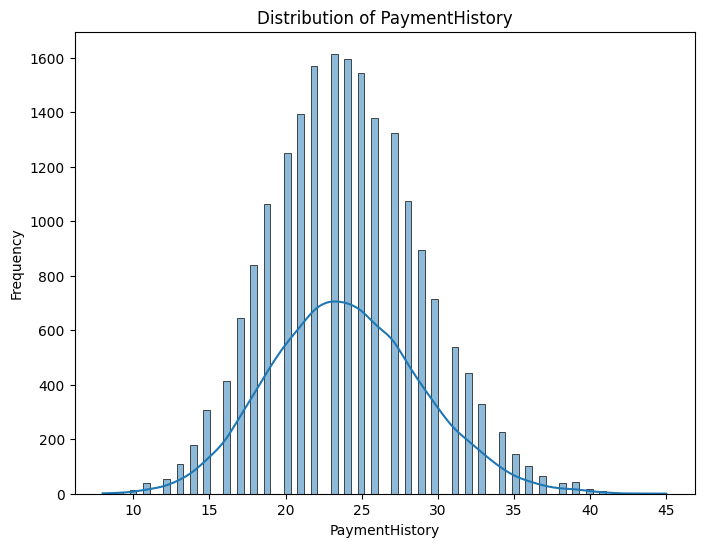

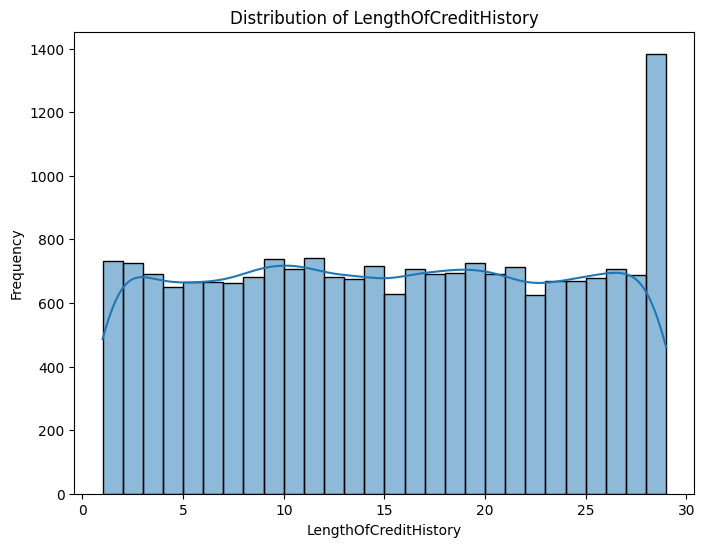

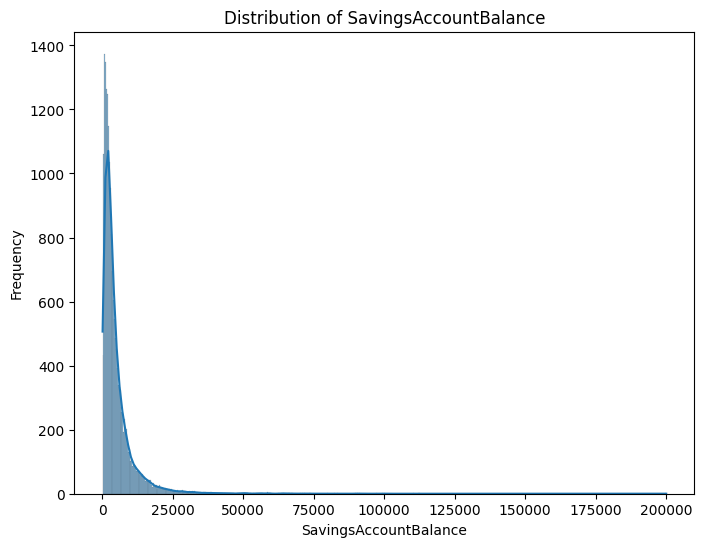

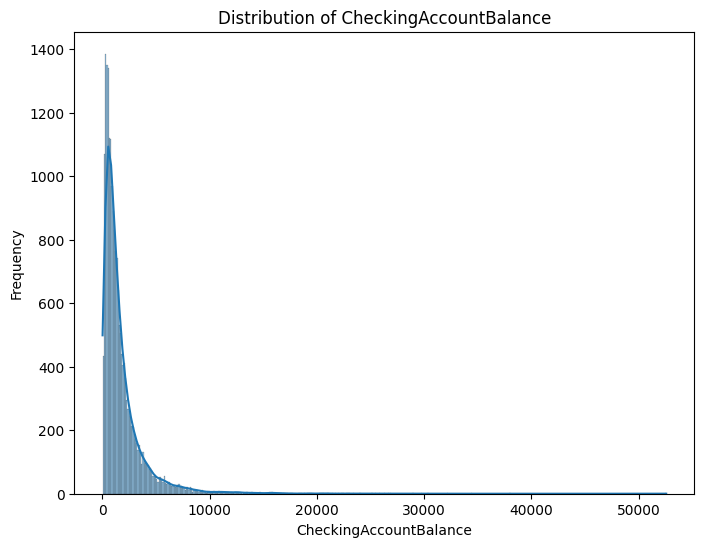

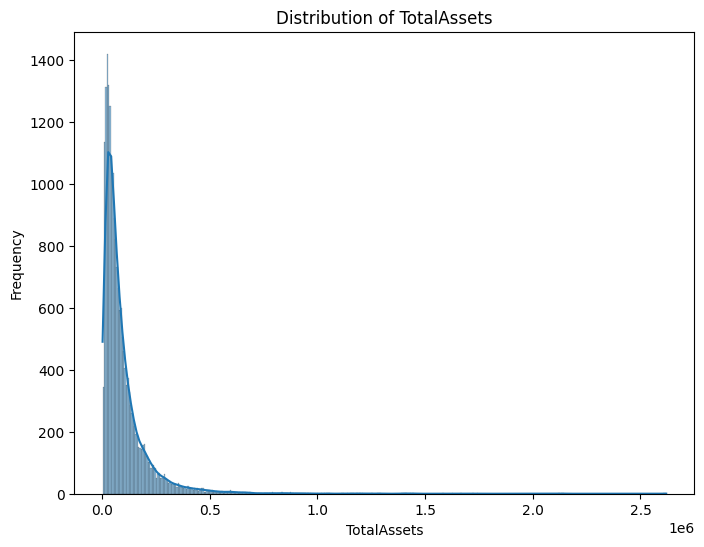

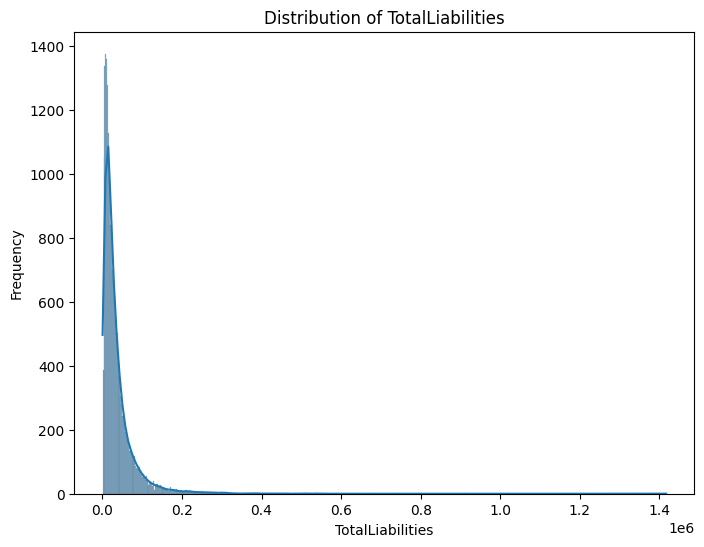

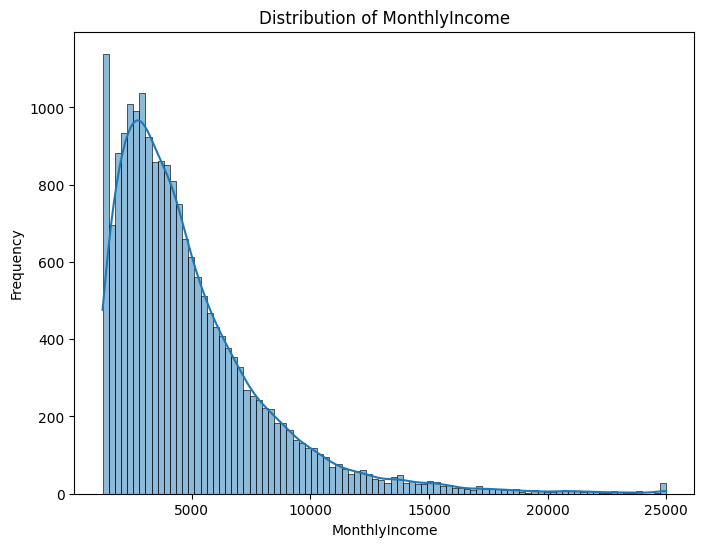

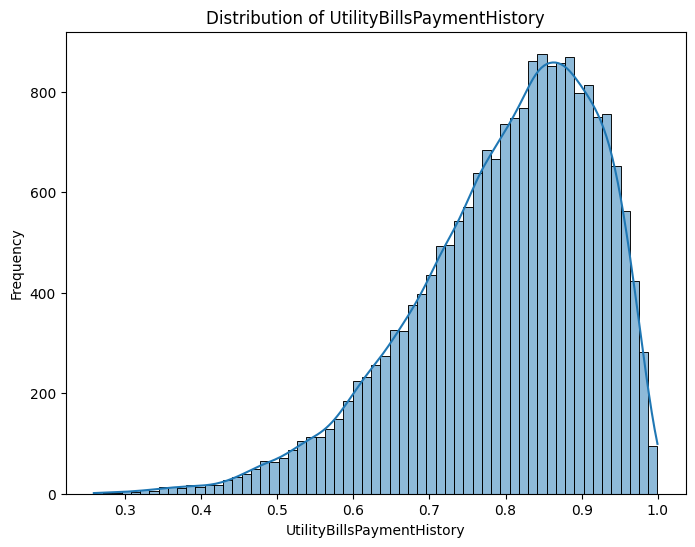

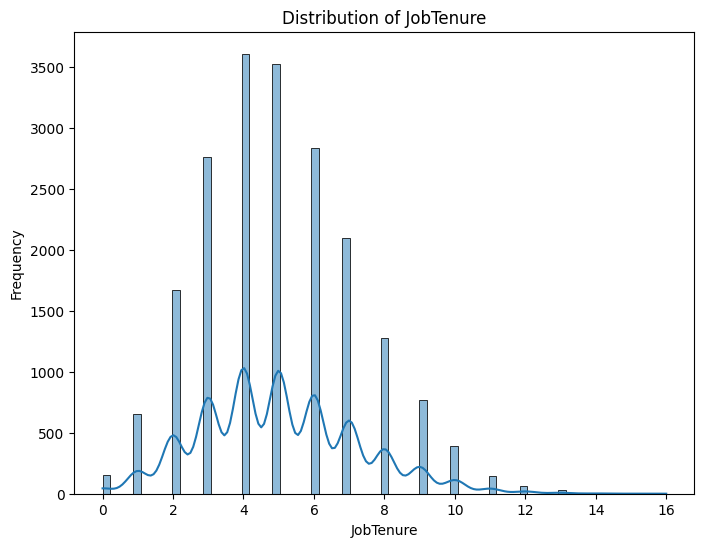

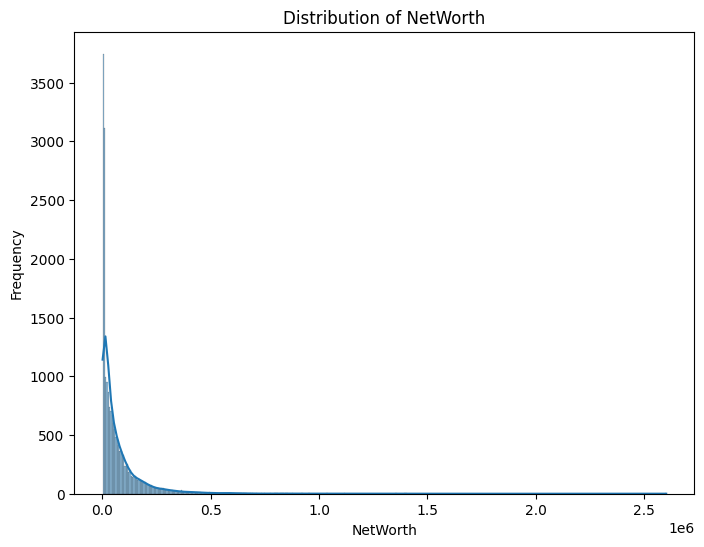

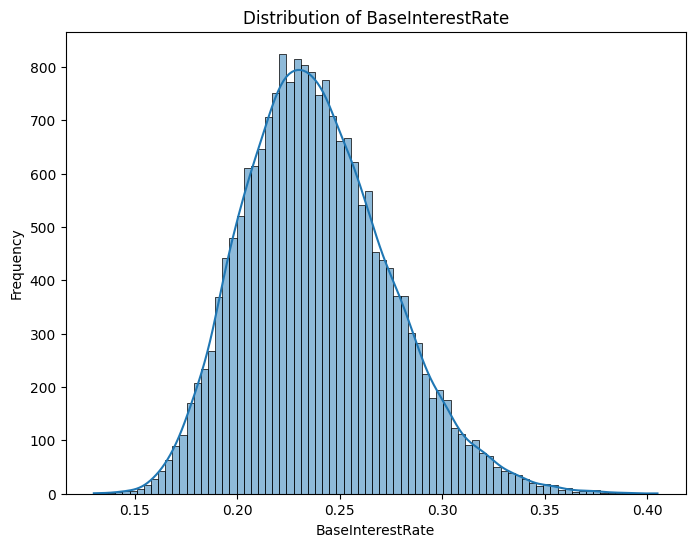

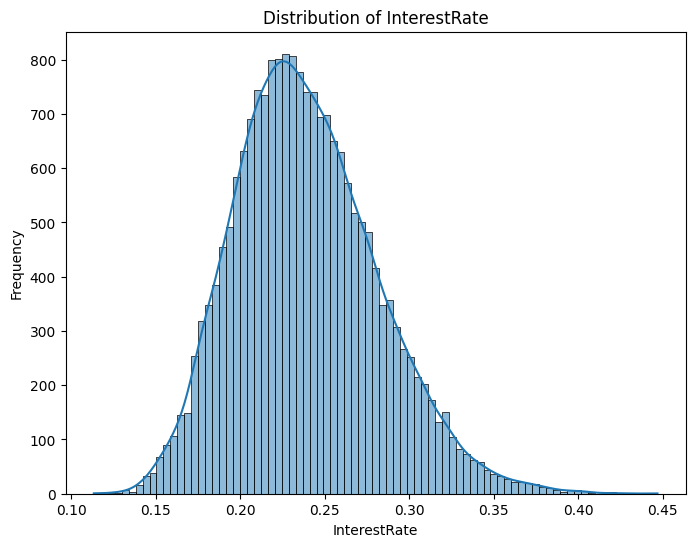

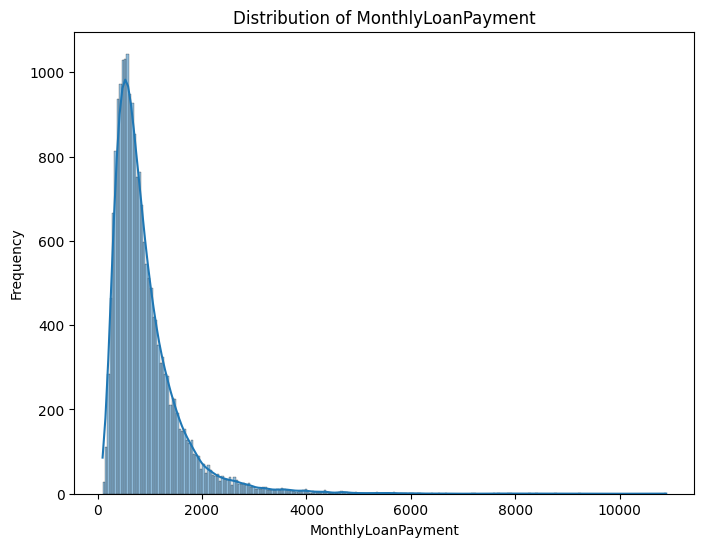

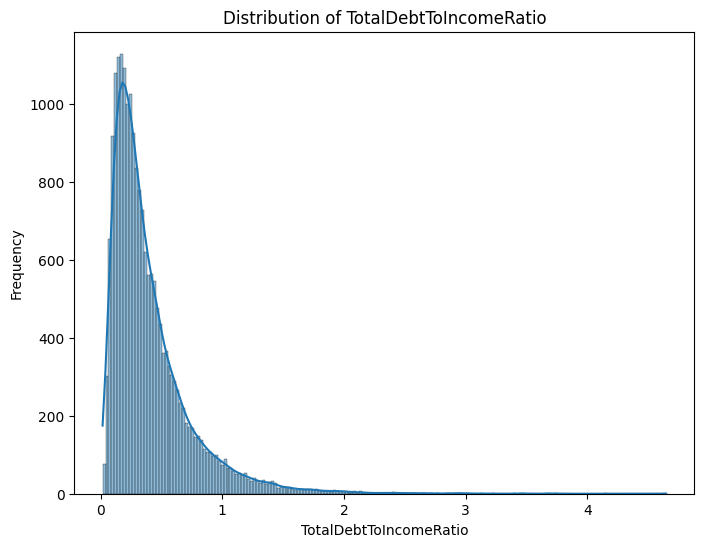

In [ ]:
# Plot distribution for each numeric variable

for col in X.columns:
    if pd.api.types.is_numeric_dtype(X[col]):
        plt.figure(figsize=(8, 6))
        sns.histplot(X[col], kde=True)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.show()

In [ ]:
# check variables have skewness more than 1 and then ckeck are they only have 0,1 values. if not, use logarithamic transformation for that variables
for col in X.columns:
    if pd.api.types.is_numeric_dtype(X[col]):
        skew_value = X[col].skew()
        print(f"Skewness of {col}: {skew_value}")
        if abs(skew_value) > 1:
            unique_values = X[col].unique()
            if set(unique_values) != {0,1}:
                print(f"Applying log transformation to {col}")
                # Add 1 to handle potential zero values before log transformation
                X[col] = np.log1p(X[col])
                print(f"Skewness after transformation of {col}: {X[col].skew()}")
            else:
                print(f"Variable {col} only contains 0 and 1. No transformation applied.")

Skewness of Age: 0.1859639313618668
Skewness of AnnualIncome: 2.088947958524819
Applying log transformation to AnnualIncome
Skewness after transformation of AnnualIncome: 0.15867184767171486
Skewness of CreditScore: -0.5967271396622066
Skewness of Experience: 0.3399806516192076
Skewness of LoanAmount: 1.833687791747409
Applying log transformation to LoanAmount
Skewness after transformation of LoanAmount: 0.01640514251762184
Skewness of LoanDuration: 0.6513298388142006
Skewness of NumberOfDependents: 0.6399193421240162
Skewness of MonthlyDebtPayments: 1.6534346778754938
Applying log transformation to MonthlyDebtPayments
Skewness after transformation of MonthlyDebtPayments: -0.020966211494096085
Skewness of CreditCardUtilizationRate: 0.6011310014982273
Skewness of NumberOfOpenCreditLines: 0.5996617764765775
Skewness of NumberOfCreditInquiries: 1.012064821175029
Applying log transformation to NumberOfCreditInquiries
Skewness after transformation of NumberOfCreditInquiries: 0.1182030562983

In [ ]:
# Check variables that have skewness more than 1

for col in X.columns:
    if pd.api.types.is_numeric_dtype(X[col]):
        skew_value = X[col].skew()
        if abs(skew_value) > 1:
            print(f"The variable {col} has skewness more than 1: {skew_value}")

The variable BankruptcyHistory has skewness more than 1: 4.017671996623785
The variable PreviousLoanDefaults has skewness more than 1: 2.665940998996204
The variable TotalDebtToIncomeRatio has skewness more than 1: 1.4119276366821176


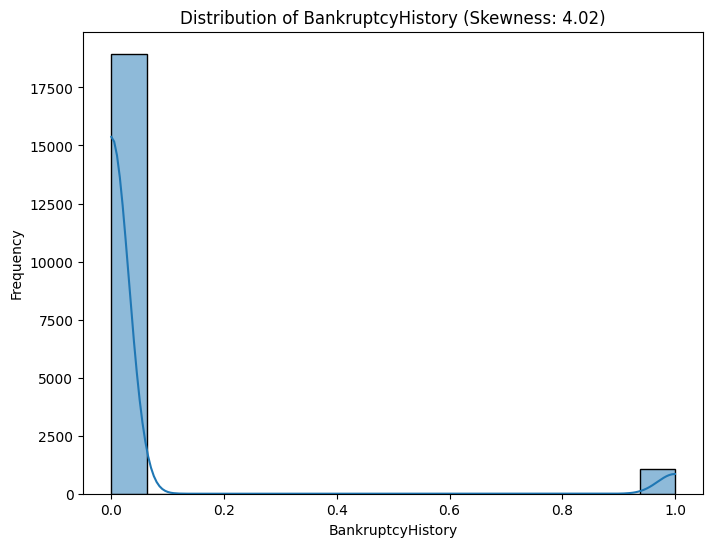

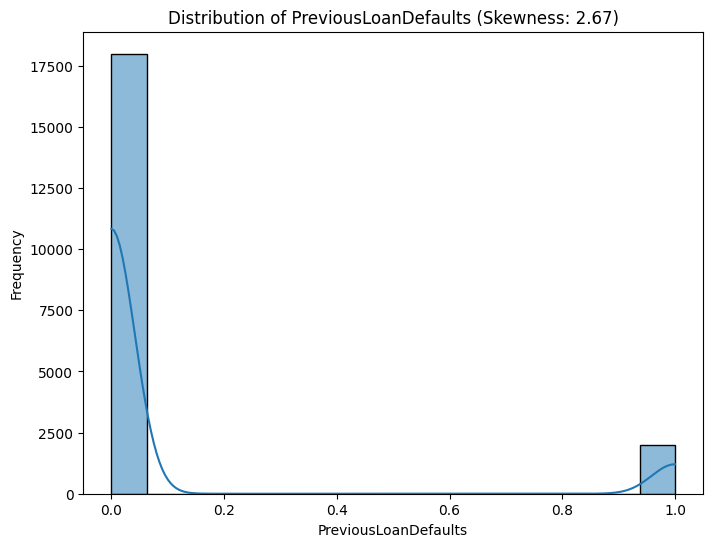

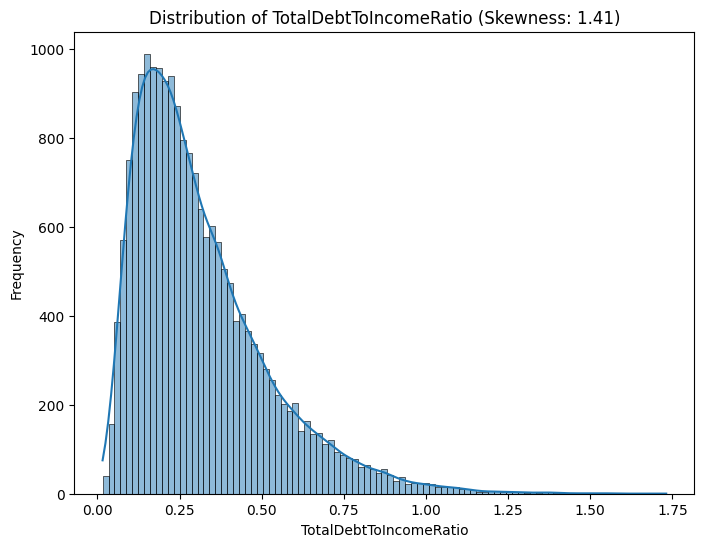

In [ ]:
# Plot variables that have more than 1 skewness

import matplotlib.pyplot as plt
import seaborn as sns

for col in X.columns:
    if pd.api.types.is_numeric_dtype(X[col]):
        skew_value = X[col].skew()
        if abs(skew_value) > 1:
            plt.figure(figsize=(8, 6))
            sns.histplot(X[col], kde=True)
            plt.title(f'Distribution of {col} (Skewness: {skew_value:.2f})')
            plt.xlabel(col)
            plt.ylabel('Frequency')
            plt.show()

In [ ]:
# Apply square root transformation to 'totalDebtToIncomeRatio'
X['TotalDebtToIncomeRatio'] = np.sqrt(X['TotalDebtToIncomeRatio'])

# Print skewness after transformation
print(f"Skewness of totalDebtToIncomeRatio after square root transformation: {X['TotalDebtToIncomeRatio'].skew()}")


Skewness of totalDebtToIncomeRatio after square root transformation: 0.5764668065546789


In [ ]:
# find outliers
def find_outliers_iqr(X):
    outliers = {}
    for col in X.select_dtypes(include=['number']):


        Q1 = X[col].quantile(0.25)
        Q3 = X[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers_col = X[(X[col] < lower_bound) | (X[col] > upper_bound)]
        if not outliers_col.empty:
            outliers[col] = outliers_col.shape[0]

    return outliers

outliers_iqr = find_outliers_iqr(X)
print("\nColumns with outliers (using percentile method):")
for col, count in outliers_iqr.items():
    print(f"- {col}: {count} outliers")



Columns with outliers (using percentile method):
- Age: 64 outliers
- AnnualIncome: 61 outliers
- CreditScore: 242 outliers
- Experience: 75 outliers
- LoanAmount: 126 outliers
- MonthlyDebtPayments: 135 outliers
- CreditCardUtilizationRate: 130 outliers
- NumberOfOpenCreditLines: 249 outliers
- DebtToIncomeRatio: 143 outliers
- BankruptcyHistory: 1048 outliers
- PreviousLoanDefaults: 2001 outliers
- PaymentHistory: 241 outliers
- SavingsAccountBalance: 174 outliers
- CheckingAccountBalance: 130 outliers
- TotalAssets: 96 outliers
- TotalLiabilities: 131 outliers
- MonthlyIncome: 55 outliers
- UtilityBillsPaymentHistory: 294 outliers
- JobTenure: 251 outliers
- BaseInterestRate: 219 outliers
- InterestRate: 222 outliers
- MonthlyLoanPayment: 206 outliers
- TotalDebtToIncomeRatio: 199 outliers


In [ ]:
X.shape

(20000, 34)

In [ ]:
def cap_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[column] = df[column].apply(lambda x: lower_bound if x < lower_bound else upper_bound if x > upper_bound else x)
    return df

# Example usage for all numeric columns:
for col in X.select_dtypes(include=['number']).columns:
    X = cap_outliers_iqr(X, col)


In [ ]:
X.shape

(20000, 34)

In [ ]:
print(X['BankruptcyHistory'])

0        0.0
1        0.0
2        0.0
3        0.0
4        0.0
        ... 
19995    0.0
19996    0.0
19997    0.0
19998    0.0
19999    0.0
Name: BankruptcyHistory, Length: 20000, dtype: float64


In [ ]:
X.head()

,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio
0,1/1/2018,45.0,10.595359,617.0,Employed,Master,22.0,9.484405,48,Married,...,11.892129,9.861832,8.110728,0.724972,10.5,11.751383,0.199652,0.227590,6.042172,0.407955
1,1/2/2018,38.0,10.589358,628.0,Employed,Associate,15.0,10.167619,48,Single,...,10.881908,9.169102,8.104729,0.935132,3.0,10.683042,0.207045,0.201077,6.678410,0.573757
2,1/3/2018,47.0,10.614597,570.0,Employed,Bachelor,26.0,9.777244,36,Married,...,10.133686,11.766598,8.129961,0.872241,6.0,8.557567,0.217627,0.212548,6.503400,0.616371
3,1/4/2018,58.0,11.143093,545.0,Employed,High School,34.0,10.542680,96,Single,...,11.560028,8.588769,8.658345,0.896155,5.0,11.507440,0.300398,0.300911,6.955123,0.521909
4,1/5/2018,37.0,11.545054,594.0,Employed,Associate,17.0,9.125327,36,Married,...,12.406177,9.757710,9.060254,0.941369,5.0,12.332793,0.197184,0.175990,5.802659,0.260489


In [ ]:
for col in X.columns:
    print(f"Data type of {col}: {X[col].dtype}")

Data type of ApplicationDate: object
Data type of Age: float64
Data type of AnnualIncome: float64
Data type of CreditScore: float64
Data type of EmploymentStatus: object
Data type of EducationLevel: object
Data type of Experience: float64
Data type of LoanAmount: float64
Data type of LoanDuration: int64
Data type of MaritalStatus: object
Data type of NumberOfDependents: int64
Data type of HomeOwnershipStatus: object
Data type of MonthlyDebtPayments: float64
Data type of CreditCardUtilizationRate: float64
Data type of NumberOfOpenCreditLines: float64
Data type of NumberOfCreditInquiries: float64
Data type of DebtToIncomeRatio: float64
Data type of BankruptcyHistory: float64
Data type of LoanPurpose: object
Data type of PreviousLoanDefaults: float64
Data type of PaymentHistory: float64
Data type of LengthOfCreditHistory: int64
Data type of SavingsAccountBalance: float64
Data type of CheckingAccountBalance: float64
Data type of TotalAssets: float64
Data type of TotalLiabilities: float64
D

In [ ]:
# since applicationDate not important remove ApplicationDate column from X
X = X.drop('ApplicationDate', axis=1)

In [ ]:
X.head()

,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,...,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio
0,45.0,10.595359,617.0,Employed,Master,22.0,9.484405,48,Married,2,...,11.892129,9.861832,8.110728,0.724972,10.5,11.751383,0.199652,0.227590,6.042172,0.407955
1,38.0,10.589358,628.0,Employed,Associate,15.0,10.167619,48,Single,1,...,10.881908,9.169102,8.104729,0.935132,3.0,10.683042,0.207045,0.201077,6.678410,0.573757
2,47.0,10.614597,570.0,Employed,Bachelor,26.0,9.777244,36,Married,2,...,10.133686,11.766598,8.129961,0.872241,6.0,8.557567,0.217627,0.212548,6.503400,0.616371
3,58.0,11.143093,545.0,Employed,High School,34.0,10.542680,96,Single,1,...,11.560028,8.588769,8.658345,0.896155,5.0,11.507440,0.300398,0.300911,6.955123,0.521909
4,37.0,11.545054,594.0,Employed,Associate,17.0,9.125327,36,Married,1,...,12.406177,9.757710,9.060254,0.941369,5.0,12.332793,0.197184,0.175990,5.802659,0.260489


In [ ]:
X = pd.get_dummies(X, drop_first=True) # One-hot encode categorical features
print(X.head())

    Age  AnnualIncome  CreditScore  Experience  LoanAmount  LoanDuration  \
0  45.0     10.595359        617.0        22.0    9.484405            48   
1  38.0     10.589358        628.0        15.0   10.167619            48   
2  47.0     10.614597        570.0        26.0    9.777244            36   
3  58.0     11.143093        545.0        34.0   10.542680            96   
4  37.0     11.545054        594.0        17.0    9.125327            36   

   NumberOfDependents  MonthlyDebtPayments  CreditCardUtilizationRate  \
0                   2             5.214936                   0.354418   
1                   1             6.208590                   0.087827   
2                   2             6.805723                   0.137414   
3                   1             6.628041                   0.267587   
4                   1             5.616771                   0.320535   

   NumberOfOpenCreditLines  ...  MaritalStatus_Married  MaritalStatus_Single  \
0                      1

In [ ]:
# Use standard scaling to numerical variables

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numerical_cols = X.select_dtypes(include=['number']).columns
scaler.fit(X[numerical_cols])
X[numerical_cols] = scaler.transform(X[numerical_cols])

In [ ]:
# Iterate through boolean columns and convert them to 0 and 1
for col in X.columns:
    if pd.api.types.is_bool_dtype(X[col]):
        X[col] = X[col].astype(int)

In [ ]:
X.head()

,Age,AnnualIncome,CreditScore,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,...,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Widowed,HomeOwnershipStatus_Other,HomeOwnershipStatus_Own,HomeOwnershipStatus_Rent,LoanPurpose_Debt Consolidation,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other
0,0.453940,-0.331795,0.897666,0.398759,-1.019979,-0.245578,0.348195,-1.574157,0.430534,-1.190645,...,1,0,0,0,1,0,0,0,1,0
1,-0.150226,-0.341644,1.116339,-0.222479,0.345577,-0.245578,-0.373154,0.426393,-1.248390,1.184352,...,0,1,0,0,0,0,1,0,0,0
2,0.626558,-0.300217,-0.036666,0.753752,-0.434676,-0.732113,0.348195,1.628616,-0.936102,-0.596896,...,1,0,0,0,0,1,0,1,0,0
3,1.575961,0.567257,-0.533650,1.463739,1.095219,1.700559,-0.373154,1.270886,-0.116305,-0.596896,...,0,1,0,0,0,0,0,0,1,0
4,-0.236535,1.227037,0.440440,-0.044982,-1.737677,-0.732113,-0.373154,-0.765131,0.217150,-1.784395,...,1,0,0,0,0,0,1,0,0,0


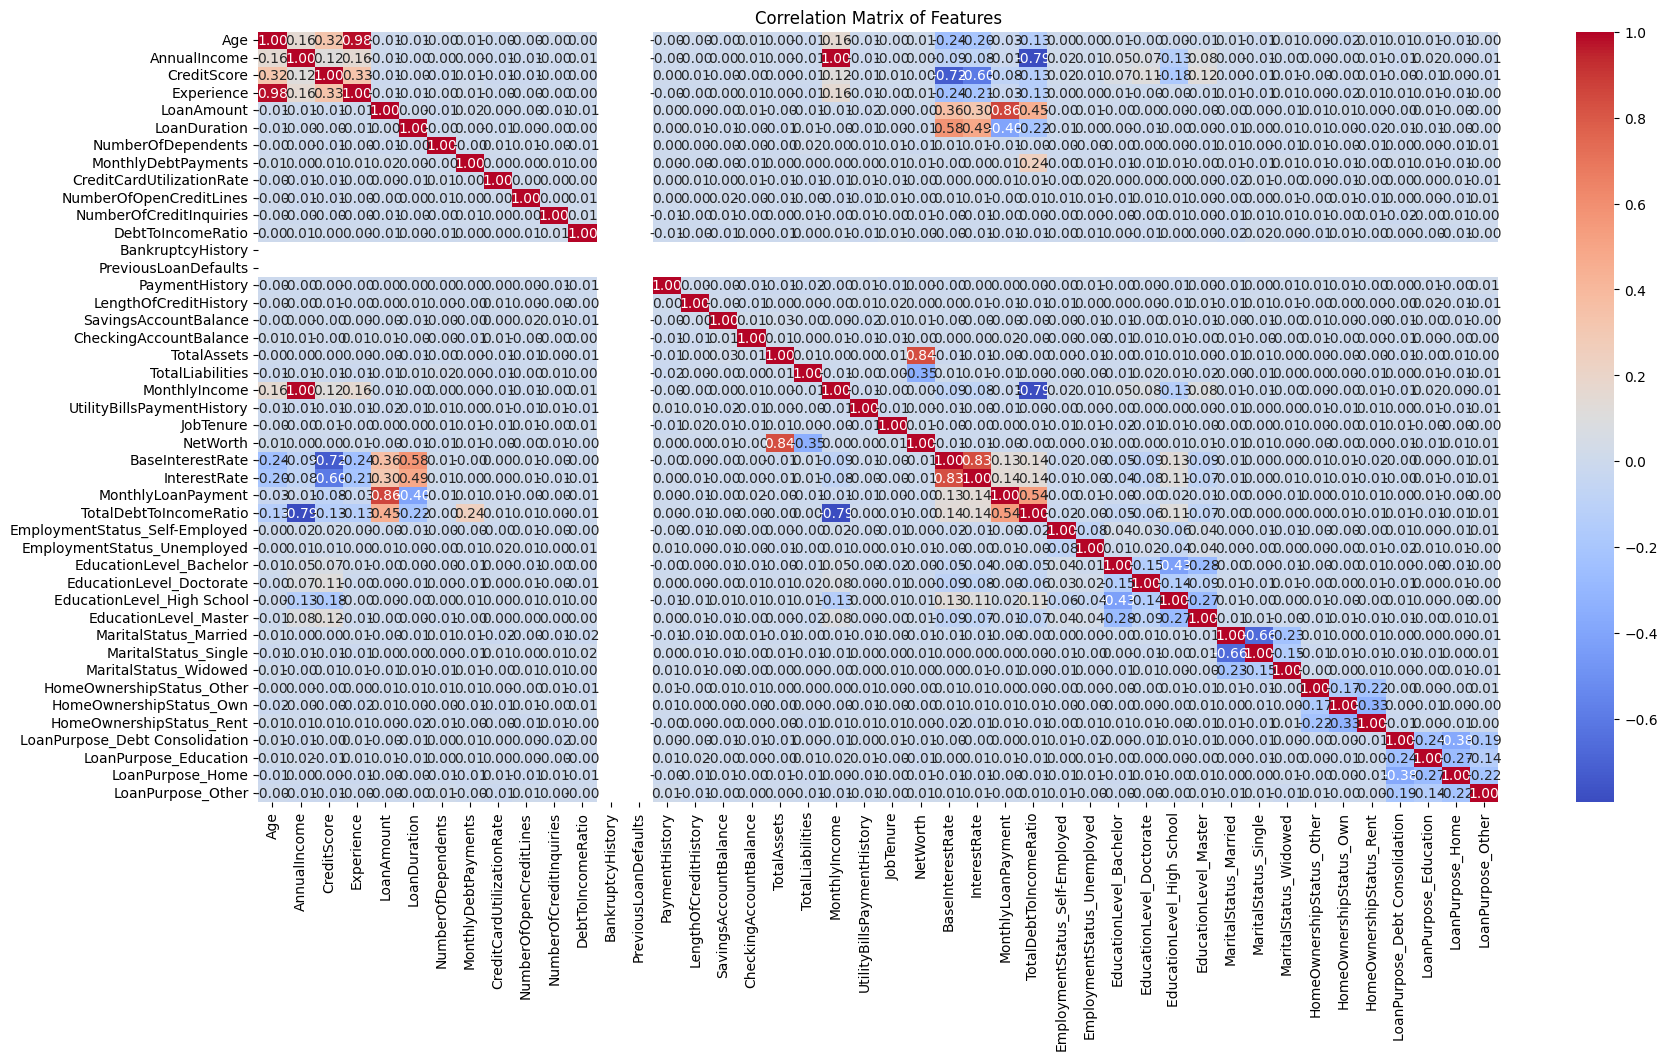

In [ ]:
# Calculate the correlation matrix
correlation_matrix = X.corr()

# Plot the correlation matrix using a heatmap
plt.figure(figsize=(20, 10))  # Adjust figure size as needed
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.show()

In [ ]:
mask=np.triu(np.ones_like(correlation_matrix,dtype=bool))
filtered_corr_matrix = correlation_matrix.where(mask)
np.fill_diagonal(filtered_corr_matrix.values, np.nan)

# Identify columns with correlation greater than 0.8
high_corr_pairs = []
for col in filtered_corr_matrix.columns:
    for idx in filtered_corr_matrix.index:
        value = filtered_corr_matrix.loc[idx, col]
        if not pd.isna(value) and abs(value) > 0.8:
            high_corr_pairs.append((idx, col,value))

# Print pairs of columns with high correlation
if high_corr_pairs:
    print("Columns with correlation > 0.8:")
    for pair in high_corr_pairs:
        print(f"{pair[0]} - {pair[1]} :{pair[2]:.2f}")
else:
    print("No columns with correlation > 0.8 found.")

Columns with correlation > 0.8:
Age - Experience :0.98
AnnualIncome - MonthlyIncome :1.00
TotalAssets - NetWorth :0.84
BaseInterestRate - InterestRate :0.83
LoanAmount - MonthlyLoanPayment :0.86


In [ ]:
# Define the columns to drop
columns_to_drop = ['Experience','MonthlyIncome','TotalAssets','BaseInterestRate','MonthlyLoanPayment']

X = X.drop(columns=columns_to_drop)

print(f"Dropped columns: {columns_to_drop}")
print(f"Updated DataFrame shape: {X.shape}")
print(f"Remaining columns: {X.columns.tolist()}")

Dropped columns: ['Experience', 'MonthlyIncome', 'TotalAssets', 'BaseInterestRate', 'MonthlyLoanPayment']
Updated DataFrame shape: (20000, 39)
Remaining columns: ['Age', 'AnnualIncome', 'CreditScore', 'LoanAmount', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'BankruptcyHistory', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalLiabilities', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth', 'InterestRate', 'TotalDebtToIncomeRatio', 'EmploymentStatus_Self-Employed', 'EmploymentStatus_Unemployed', 'EducationLevel_Bachelor', 'EducationLevel_Doctorate', 'EducationLevel_High School', 'EducationLevel_Master', 'MaritalStatus_Married', 'MaritalStatus_Single', 'MaritalStatus_Widowed', 'HomeOwnershipStatus_Other', 'HomeOwnershipStatus_Own', 'HomeOwnershipStatus_Rent', 'LoanPurpose_Debt Consolidation

In [ ]:
print(y.head())

0    0
1    0
2    0
3    0
4    1
Name: LoanApproved, dtype: int64


In [ ]:
# Calculate the percentage of 1s and 0s in the 'y' variable

ones_percentage = (y == 1).sum() / len(y) * 100
zeros_percentage = (y == 0).sum() / len(y) * 100
print(f"1s in y: {(y==1).sum():}")
print(f"Percentage of 1s in y: {ones_percentage:.2f}%")
print(f"Percentage of 0s in y: {zeros_percentage:.2f}%")

1s in y: 4780
Percentage of 1s in y: 23.90%
Percentage of 0s in y: 76.10%


In [ ]:
# Split X to X_train and X_test and split y to Y_train and y_test

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [ ]:
# Use SMOTE and upsample the dataset
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

print(f"Original dataset shape: {X_train.shape}, {y_train.shape}")
print(f"Resampled dataset shape: {X_resampled.shape}, {y_resampled.shape}")

ones_percentage_resampled = (y_resampled == 1).sum() / len(y_resampled) * 100
zeros_percentage_resampled = (y_resampled == 0).sum() / len(y_resampled) * 100

print(f"1s in y_resampled: {(y_resampled==1).sum():}")
print(f"Percentage of 1s in y_resampled: {ones_percentage_resampled:.2f}%")
print(f"Percentage of 0s in y_resampled: {zeros_percentage_resampled:.2f}%")
X_train=X_resampled
y_train=y_resampled

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


Original dataset shape: (16000, 39), (16000,)
Resampled dataset shape: (24474, 39), (24474,)
1s in y_resampled: 12237
Percentage of 1s in y_resampled: 50.00%
Percentage of 0s in y_resampled: 50.00%


In [ ]:
X_train.shape

(24474, 39)

Accuracy for logistic_regression: 0.93
Classification Report for logistic_regression:
              precision    recall  f1-score   support

           0       0.97      0.94      0.95      2983
           1       0.83      0.90      0.87      1017

    accuracy                           0.93      4000
   macro avg       0.90      0.92      0.91      4000
weighted avg       0.93      0.93      0.93      4000

Confusion Matrix for logistic_regression:
[[2801  182]
 [  98  919]]


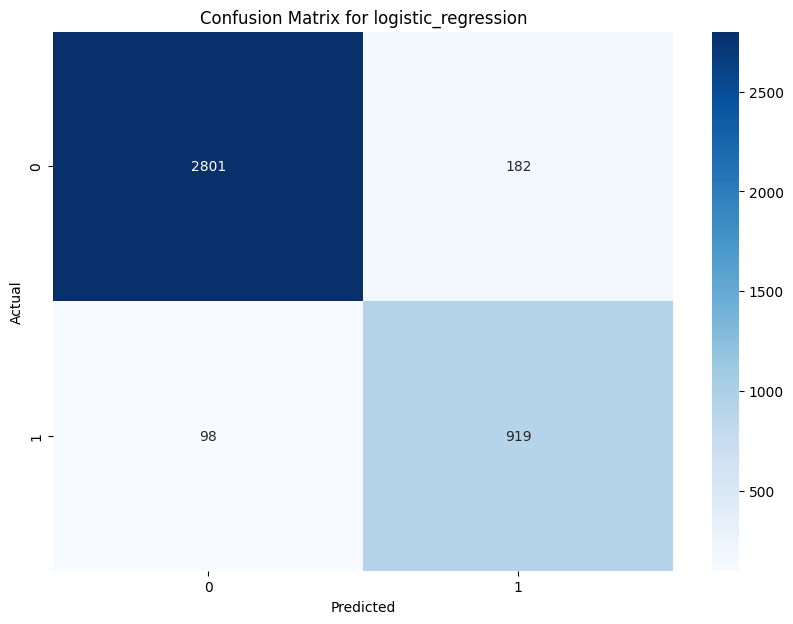


--------------------------------------------------

Accuracy for random_forest: 0.91725
Classification Report for random_forest:
              precision    recall  f1-score   support

           0       0.95      0.94      0.94      2983
           1       0.82      0.86      0.84      1017

    accuracy                           0.92      4000
   macro avg       0.89      0.90      0.89      4000
weighted avg       0.92      0.92      0.92      4000

Confusion Matrix for random_forest:
[[2796  187]
 [ 144  873]]


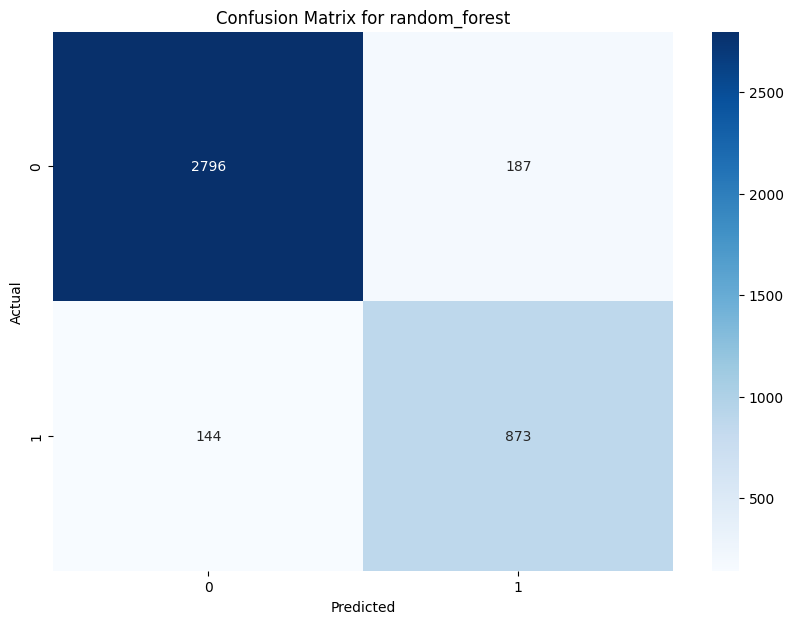


--------------------------------------------------

Accuracy for xgboost: 0.93825
Classification Report for xgboost:
              precision    recall  f1-score   support

           0       0.97      0.95      0.96      2983
           1       0.86      0.90      0.88      1017

    accuracy                           0.94      4000
   macro avg       0.91      0.93      0.92      4000
weighted avg       0.94      0.94      0.94      4000

Confusion Matrix for xgboost:
[[2837  146]
 [ 101  916]]


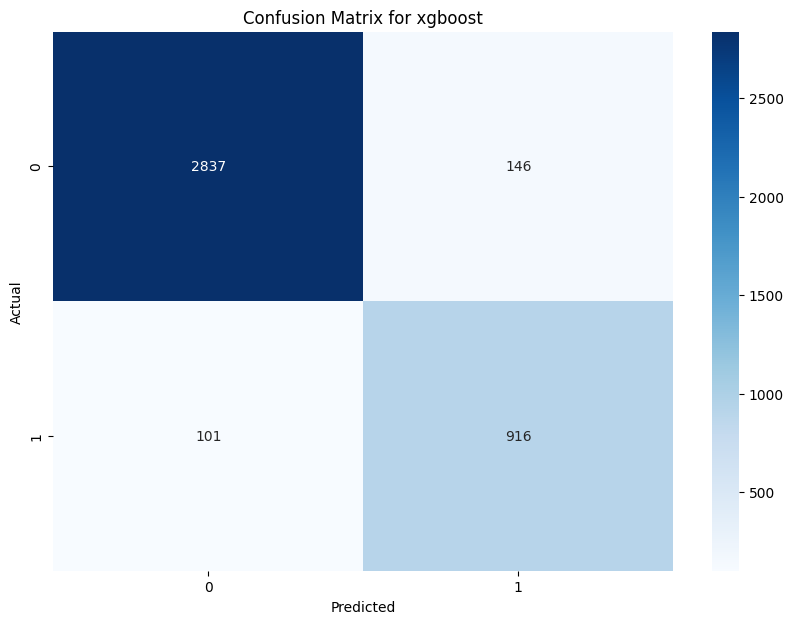


--------------------------------------------------

Accuracy for svm: 0.942
Classification Report for svm:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      2983
           1       0.88      0.89      0.89      1017

    accuracy                           0.94      4000
   macro avg       0.92      0.93      0.92      4000
weighted avg       0.94      0.94      0.94      4000

Confusion Matrix for svm:
[[2862  121]
 [ 111  906]]


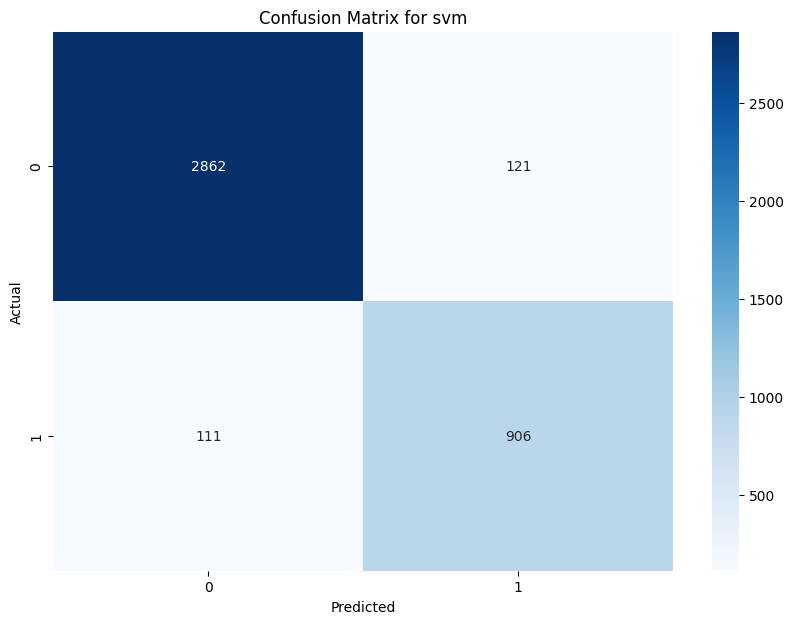


--------------------------------------------------

Accuracy for voting classifier: 0.94225
Classification Report for voting classifier:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      2983
           1       0.88      0.90      0.89      1017

    accuracy                           0.94      4000
   macro avg       0.92      0.93      0.92      4000
weighted avg       0.94      0.94      0.94      4000

Confusion Matrix for voting classifier:
[[2856  127]
 [ 104  913]]


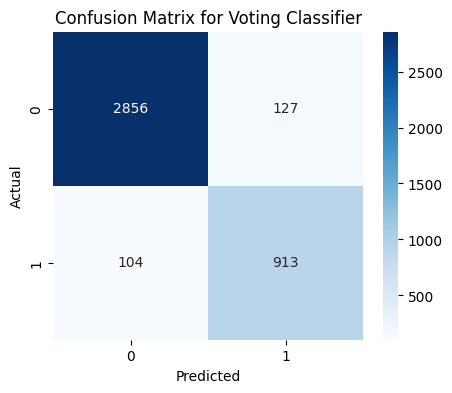

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize models with predefined hyperparameters
models = {
    'logistic_regression': LogisticRegression(C=1.0, solver='liblinear', random_state=42),
    'random_forest': RandomForestClassifier(n_estimators=100, max_depth=None, min_samples_split=2, random_state=42),
    'xgboost': XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42),
    'svm': SVC(C=1.0, kernel='rbf', gamma='scale', probability=True, random_state=42)
}

for model_name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy for {model_name}: {accuracy}")

    print(f"Classification Report for {model_name}:")
    print(classification_report(y_test, y_pred))

    conf_matrix = confusion_matrix(y_test, y_pred)
    print(f"Confusion Matrix for {model_name}:")
    print(conf_matrix)

    # Plot confusion matrix using seaborn
    plt.figure(figsize=(10, 7))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix for {model_name}")
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

    print("\n" + "-"*50 + "\n")

# Create a voting classifier
voting_clf = VotingClassifier(
    estimators=[
        ('lr', models['logistic_regression']),
        ('rf', models['random_forest']),
        ('svm', models['svm'])
    ],
    voting='soft'  # 'soft'
)

# Train the voting classifier
voting_clf.fit(X_train, y_train)

# Make predictions with the voting classifier
y_pred = voting_clf.predict(X_test)

# Evaluate the voting classifier
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy for voting classifier: {accuracy}")
print("Classification Report for voting classifier:")
print(classification_report(y_test, y_pred))

conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix for voting classifier:")
print(conf_matrix)

# Plot confusion matrix for voting classifier using seaborn
plt.figure(figsize=(5,4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix for Voting Classifier")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


In [ ]:
# To the model who made using voting classifier, make the pkl file
import pickle

filename = 'voting_classifier_model.pkl'
pickle.dump(voting_clf, open(filename, 'wb'))